# Raidium Challenge 2025 — Three-Model Comparison (GPU)

**Environment:** Google Colab + T4 GPU  
**Before running:** `Runtime → Change runtime type → T4 GPU → Save`

Three models of increasing sophistication are trained and evaluated against the same
200-image balanced validation split so each improvement is directly attributable to
the architectural change:

| # | Model | Key idea |
|---|---|---|
| 1 | **ShallowSegNet** | 3-conv supervised baseline; local-texture only |
| 2 | **U-Net (small)** | Skip connections; multi-scale context |
| 3 | **U-Net+ (deep)** | Wider U-Net + class-weighted CE + Dice combo loss |

---
## Table of Contents
1. [Mount Google Drive & Extract Data](#setup)
2. [Imports & Config](#imports)
3. [Load Data](#data)
4. [Dataset & DataLoader](#dataset)
5. [Model Architectures](#models)
6. [Loss, Optimiser & Training Loop](#training)
7. [Train All Three Models](#train-all)
8. [Evaluation & Comparison](#evaluation)
9. [Submission](#submission)


## 1. Mount Google Drive & Extract Data <a id='setup'></a>

In [1]:
from google.colab import drive
import shutil, zipfile
from pathlib import Path

# ── Mount Drive ───────────────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── Set this to wherever you put your files in Drive ─────────────────────────
DRIVE_DIR = Path("/content/drive/MyDrive/raidium")

# ── Local working directory on Colab's fast disk ─────────────────────────────
LOCAL_DIR = Path("/content/raidium")
LOCAL_DIR.mkdir(exist_ok=True)

# ── Copy flat files ───────────────────────────────────────────────────────────
for filename in ["y_train.csv", "annotated_labels.json"]:
    src = DRIVE_DIR / filename
    dst = LOCAL_DIR / filename
    if not dst.exists():
        print(f"Copying {filename} …")
        shutil.copy(str(src), str(dst))
    else:
        print(f"{filename} already present, skipping.")

# ── Extract zips (skip if already extracted) ─────────────────────────────────
for zip_name, extract_check in [
    ("x_train.zip", LOCAL_DIR / "train-images"),
    ("x_test.zip",  LOCAL_DIR / "test-images"),
]:
    if extract_check.exists():
        print(f"{zip_name} already extracted, skipping.")
    else:
        zip_src = DRIVE_DIR / zip_name
        zip_dst = LOCAL_DIR / zip_name
        print(f"Copying {zip_name} from Drive …")
        shutil.copy(str(zip_src), str(zip_dst))
        print(f"Extracting {zip_name} …")
        with zipfile.ZipFile(str(zip_dst), "r") as zf:
            zf.extractall(str(LOCAL_DIR))
        zip_dst.unlink()
        print("Done.")

# ── Verify ────────────────────────────────────────────────────────────────────
train_img_dir = LOCAL_DIR / "train-images"
test_img_dir  = LOCAL_DIR / "test-images"
print(f"\nTrain images : {len(list(train_img_dir.glob('*.png')))}")
print(f"Test  images : {len(list(test_img_dir.glob('*.png')))}")
print(f"Label CSV    : {(LOCAL_DIR / 'y_train.csv').exists()}")


Mounted at /content/drive
Copying y_train.csv …
Copying annotated_labels.json …
Copying x_train.zip from Drive …
Extracting x_train.zip …
Done.
Copying x_test.zip from Drive …
Extracting x_test.zip …
Done.

Train images : 2000
Test  images : 500
Label CSV    : True


## 2. Imports & Config <a id='imports'></a>

In [2]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

warnings.filterwarnings("ignore")

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch : 2.11.0+cu128
CUDA    : True
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
LOCAL_DIR     = Path("/content/raidium")
TRAIN_IMG_DIR = LOCAL_DIR / "train-images"
TEST_IMG_DIR  = LOCAL_DIR / "test-images"
LABEL_CSV     = LOCAL_DIR / "y_train.csv"

# ── Segmentation ──────────────────────────────────────────────────────────────
NUM_CLASSES = 54           # organs; class 0 = background
NUM_OUTPUTS = NUM_CLASSES + 1

# ── Training ──────────────────────────────────────────────────────────────────
IMG_SIZE    = 256          # spatial resolution fed to the network
VAL_SPLIT   = 200          # first 200 images held out for validation
BATCH_SIZE  = 8            # safe for T4 16 GB at 256×256; lower to 4 if OOM
LR          = 3e-4
SEED        = 42

# Per-model epoch counts — adjust freely
EPOCHS_SHALLOW = 15        # ~3 min on T4
EPOCHS_UNET    = 30        # ~10 min on T4
EPOCHS_UNETP   = 30        # ~12 min on T4

torch.manual_seed(SEED)
np.random.seed(SEED)
print("Config ready.")


Config ready.


## 3. Load Data <a id='data'></a>

In [4]:
def load_images(image_dir: Path) -> np.ndarray:
    """Load PNG images in strict numerical order → (N, H, W) uint8 array."""
    files = sorted(Path(image_dir).glob("*.png"), key=lambda p: int(p.stem))
    if not files:
        raise FileNotFoundError(f"No PNG files in {image_dir}")
    imgs = [np.array(Image.open(f).convert("L")) for f in tqdm(files, desc=image_dir.name)]
    return np.stack(imgs, axis=0)

print("Loading training images …")
data_train = load_images(TRAIN_IMG_DIR)
print("Loading test images …")
data_test  = load_images(TEST_IMG_DIR)

IMG_H, IMG_W = data_train.shape[1], data_train.shape[2]
print(f"\nTrain : {data_train.shape}  (N×H×W)")
print(f"Test  : {data_test.shape}")
print(f"Resolution : {IMG_H}×{IMG_W}")


Loading training images …


train-images: 100%|██████████| 2000/2000 [00:01<00:00, 1000.62it/s]


Loading test images …


test-images: 100%|██████████| 500/500 [00:00<00:00, 1034.42it/s]


Train : (2000, 256, 256)  (N×H×W)
Test  : (500, 256, 256)
Resolution : 256×256


In [5]:
print("Loading labels (may take ~30 s) …")
labels_train = pd.read_csv(LABEL_CSV, index_col=0).T    # → (N, H*W)
print(f"Labels shape : {labels_train.shape}")

assert labels_train.shape[1] == IMG_H * IMG_W, (
    f"Label columns ({labels_train.shape[1]}) != image area "
    f"({IMG_H}×{IMG_W}={IMG_H*IMG_W})"
)
print(f"Unique label values (sample): {np.unique(labels_train.values[:3])}")


Loading labels (may take ~30 s) …
Labels shape : (2000, 65536)
Unique label values (sample): [ 0  4 10 12 18 23 24 28 30 31 32 33 44 47 53]


In [6]:
# ── Reshape flat labels → (N, H, W) ─────────────────────────────────────────
masks_np = labels_train.values.reshape(-1, IMG_H, IMG_W).astype(np.int64)

# ── Train / val split ────────────────────────────────────────────────────────
val_imgs    = data_train[:VAL_SPLIT]
val_masks   = masks_np[:VAL_SPLIT]
train_imgs  = data_train[VAL_SPLIT:]
train_masks = masks_np[VAL_SPLIT:]

print(f"Train : {train_imgs.shape[0]} images")
print(f"Val   : {val_imgs.shape[0]} images")


Train : 1800 images
Val   : 200 images


In [7]:
# ── Compute class weights (inverse frequency) ────────────────────────────────
# Used by ShallowSegNet and U-Net+ to up-weight rare organs.
class_counts = np.bincount(train_masks.ravel(), minlength=NUM_OUTPUTS).astype(np.float64)
class_counts[0] /= 10                           # down-weight background
class_weights    = 1.0 / (class_counts + 1)
class_weights    = class_weights / class_weights.sum() * NUM_OUTPUTS
weight_tensor    = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights computed. Min={weight_tensor.min():.4f}  Max={weight_tensor.max():.4f}")


Class weights computed. Min=0.0006  Max=13.5847


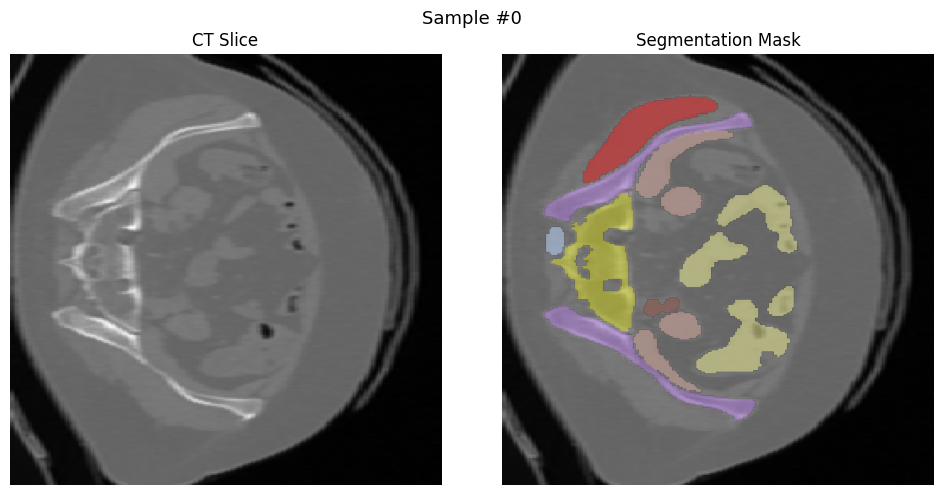

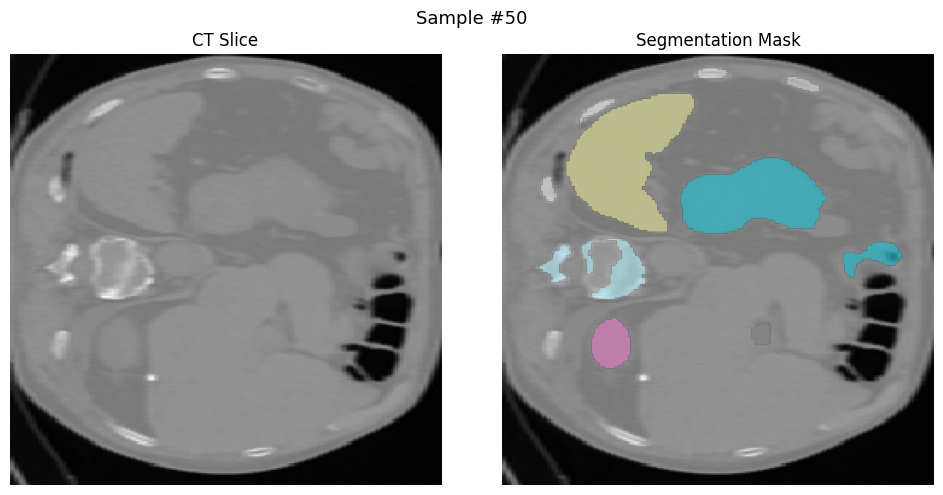

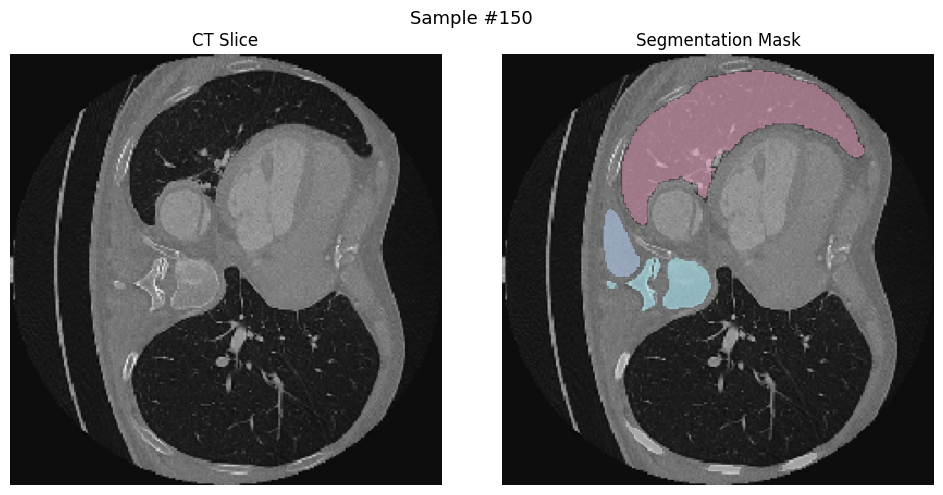

In [8]:
# ── Quick sanity visualisation ────────────────────────────────────────────────
def plot_sample(image, mask, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image, cmap="gray"); axes[0].set_title("CT Slice"); axes[0].axis("off")
    overlay = np.ma.masked_where(mask == 0, mask)
    axes[1].imshow(image, cmap="gray")
    axes[1].imshow(overlay, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[1].set_title("Segmentation Mask"); axes[1].axis("off")
    if title: fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

for idx in [0, 50, 150]:
    plot_sample(data_train[idx], masks_np[idx], title=f"Sample #{idx}")


## 4. Dataset & DataLoader <a id='dataset'></a>

In [9]:
class CTSegDataset(Dataset):
    """
    Shared dataset for all three models.
    Resizes to IMG_SIZE×IMG_SIZE on-the-fly; optional augmentation for training.
    """
    def __init__(self, images, masks, img_size=IMG_SIZE, augment=False):
        self.images   = images
        self.masks    = masks
        self.img_size = img_size
        self.augment  = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx].astype(np.float32) / 255.0).unsqueeze(0)  # (1,H,W)
        msk = torch.from_numpy(self.masks[idx])                                            # (H,W)

        # F.interpolate needs 4-D input (B,C,H,W)
        img = F.interpolate(img.unsqueeze(0), size=self.img_size,
                            mode="bilinear", align_corners=False).squeeze(0)   # (1,S,S)
        msk = F.interpolate(msk.unsqueeze(0).unsqueeze(0).float(), size=self.img_size,
                            mode="nearest").squeeze().long()                   # (S,S)

        if self.augment:
            if torch.rand(1) > 0.5:
                img = TF.hflip(img)
                msk = TF.hflip(msk.unsqueeze(0)).squeeze(0)
            if torch.rand(1) > 0.5:
                img = TF.vflip(img)
                msk = TF.vflip(msk.unsqueeze(0)).squeeze(0)
            factor = 0.8 + 0.4 * torch.rand(1).item()
            img = torch.clamp(img * factor, 0.0, 1.0)

        return img, msk   # (1,S,S), (S,S)  — msk is always 2-D, never 3-D


train_ds = CTSegDataset(train_imgs, train_masks, augment=True)
val_ds   = CTSegDataset(val_imgs,   val_masks,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs_b, msks_b = next(iter(train_loader))
print(f"Batch — images: {imgs_b.shape}, masks: {msks_b.shape}")
assert msks_b.ndim == 3, f"Expected mask (B,H,W), got {msks_b.shape}"
print("Shape check passed ✓")


Batch — images: torch.Size([8, 1, 256, 256]), masks: torch.Size([8, 256, 256])
Shape check passed ✓


## 5. Model Architectures <a id='models'></a>

### Model 1 — ShallowSegNet
3 convolutional layers + 1×1 head. No downsampling, no skip connections. Small
receptive field (7 px) — learns local texture only. Fastest to train; establishes a
supervised lower bound.

### Model 2 — U-Net (small)
4-level encoder-decoder with skip connections. Bottleneck covers the full image.
Standard architecture for medical image segmentation.

### Model 3 — U-Net+ (deep, wider)
Same topology as U-Net but with wider channels (base=48 → 768 channels at bottleneck)
and the combined CE+Dice loss with class weighting. The extra capacity and loss signal
are the only changes — directly measuring their effect on Dice.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 1: ShallowSegNet
# ─────────────────────────────────────────────────────────────────────────────
class ShallowSegNet(nn.Module):
    """3-layer conv encoder + 1×1 head. No skip connections, no downsampling."""
    def __init__(self, num_classes=NUM_OUTPUTS):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        return self.head(self.encoder(x))


# ─────────────────────────────────────────────────────────────────────────────
# Shared building blocks for U-Net variants
# ─────────────────────────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): return self.net(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([skip, x], dim=1))


# ─────────────────────────────────────────────────────────────────────────────
# Model 2: U-Net (small, base=32)
# ─────────────────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    """4-level U-Net. base=32 → ~7.7 M params. Input (B,1,H,W) → (B,C,H,W)."""
    def __init__(self, num_classes=NUM_OUTPUTS, base=32):
        super().__init__()
        self.enc1       = DoubleConv(1,       base)
        self.enc2       = Down(base,    base*2)
        self.enc3       = Down(base*2,  base*4)
        self.enc4       = Down(base*4,  base*8)
        self.bottleneck = Down(base*8,  base*16)
        self.dec4 = Up(base*16 + base*8,  base*8)
        self.dec3 = Up(base*8  + base*4,  base*4)
        self.dec2 = Up(base*4  + base*2,  base*2)
        self.dec1 = Up(base*2  + base,    base)
        self.head = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        bn = self.bottleneck(e4)
        return self.head(self.dec1(self.dec2(self.dec3(self.dec4(bn, e4), e3), e2), e1))


# ─────────────────────────────────────────────────────────────────────────────
# Model 3: U-Net+ (wider, base=48)
# ─────────────────────────────────────────────────────────────────────────────
class UNetPlus(UNet):
    """Wider U-Net (base=48 → ~17 M params). Same topology; more capacity."""
    def __init__(self, num_classes=NUM_OUTPUTS):
        super().__init__(num_classes=num_classes, base=48)


# ── Smoke tests ───────────────────────────────────────────────────────────────
dummy = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)

m1 = ShallowSegNet().to(DEVICE)
m2 = UNet().to(DEVICE)
m3 = UNetPlus().to(DEVICE)

with torch.no_grad():
    for name, m in [("ShallowSegNet", m1), ("U-Net", m2), ("U-Net+", m3)]:
        out = m(dummy)
        params = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"{name:15s}  output={tuple(out.shape)}  params={params:,}")


ShallowSegNet    output=(1, 55, 256, 256)  params=59,639
U-Net            output=(1, 55, 256, 256)  params=7,850,807
U-Net+           output=(1, 55, 256, 256)  params=17,658,295


## 6. Loss, Optimiser & Training Loop <a id='training'></a>

In [11]:
# ── Loss functions ────────────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    """Memory-efficient soft Dice — iterates over classes, no full one-hot."""
    def __init__(self, num_classes=NUM_OUTPUTS, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        dice_sum, n_valid = 0.0, 0
        for cls in range(1, self.num_classes):   # skip background
            p = probs[:, cls]
            g = (targets == cls).float()
            inter = (p * g).sum()
            card  = p.sum() + g.sum()
            if card > 0:
                dice_sum += (2.0 * inter + self.smooth) / (card + self.smooth)
                n_valid  += 1
        return 1.0 - dice_sum / max(n_valid, 1)


class CombinedLoss(nn.Module):
    """Weighted CE + soft Dice. Optionally accepts class weights for CE."""
    def __init__(self, ce_w=0.5, dice_w=0.5, class_weights=None):
        super().__init__()
        self.ce     = nn.CrossEntropyLoss(weight=class_weights)
        self.dice   = DiceLoss()
        self.ce_w   = ce_w
        self.dice_w = dice_w
    def forward(self, logits, targets):
        return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)


# ── Per-model loss & optimiser factories ─────────────────────────────────────
def make_optimizer(model, lr=LR):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

def make_scheduler(optimizer, epochs):
    return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


# ShallowSegNet uses plain CE (no class weights — shallower model, faster experiment)
loss_shallow = nn.CrossEntropyLoss()

# U-Net uses combined CE + Dice (no class weights)
loss_unet = CombinedLoss(ce_w=0.5, dice_w=0.5)

# U-Net+ uses combined CE + Dice with class weights
loss_unetp = CombinedLoss(ce_w=0.5, dice_w=0.5, class_weights=weight_tensor)

print("Loss functions ready.")


Loss functions ready.


In [12]:
# ── Training / validation loop ────────────────────────────────────────────────
def run_epoch(loader, model, criterion, optimizer=None, scaler=None):
    """
    One epoch of training (optimizer!=None) or validation.
    Uses automatic mixed precision when scaler is provided (GPU only).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for imgs, masks in tqdm(loader, desc="train" if is_train else "val ", leave=False):
            imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
            if is_train and scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(imgs)
                    loss   = criterion(logits, masks)
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                    logits = model(imgs)
                    loss   = criterion(logits, masks)
                if is_train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


def train_model(model, criterion, epochs, save_name, lr=LR):
    """
    Full training run for one model.
    Returns history dict and loads the best checkpoint into `model` before returning.
    """
    optimizer = make_optimizer(model, lr=lr)
    scheduler = make_scheduler(optimizer, epochs)
    scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None
    best_val  = float("inf")
    history   = {"train": [], "val": []}
    ckpt_path = LOCAL_DIR / save_name

    for epoch in range(1, epochs + 1):
        tr  = run_epoch(train_loader, model, criterion, optimizer, scaler)
        val = run_epoch(val_loader,   model, criterion)
        scheduler.step()
        history["train"].append(tr)
        history["val"].append(val)
        improved = val < best_val
        if improved:
            best_val = val
            torch.save(model.state_dict(), str(ckpt_path))
        print(f"  Epoch {epoch:3d}/{epochs}  train={tr:.4f}  val={val:.4f}{'  ✓' if improved else ''}")

    print(f"  Best val loss: {best_val:.4f}  — checkpoint: {ckpt_path}")
    model.load_state_dict(torch.load(str(ckpt_path), map_location=DEVICE))
    return history


def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train"], label="train")
    plt.plot(history["val"],   label="val")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.legend()
    plt.tight_layout(); plt.show()

print("Training utilities ready.")


Training utilities ready.


## 7. Train All Three Models <a id='train-all'></a>

### Model 1 — ShallowSegNet

Training Model 1: ShallowSegNet


  Epoch   1/15  train=2.1651  val=1.0158  ✓


  Epoch   2/15  train=0.4691  val=0.6502  ✓


  Epoch   3/15  train=0.3021  val=0.6184  ✓


  Epoch   4/15  train=0.2718  val=0.6032  ✓


...

  Epoch  11/15  train=0.2462  val=0.5869


  Epoch  12/15  train=0.2446  val=0.5777  ✓


  Epoch  13/15  train=0.2433  val=0.5821


  Epoch  14/15  train=0.2434  val=0.5793


  Epoch  15/15  train=0.2429  val=0.5829
  Best val loss: 0.5777  — checkpoint: /content/raidium/ckpt_shallow.pt


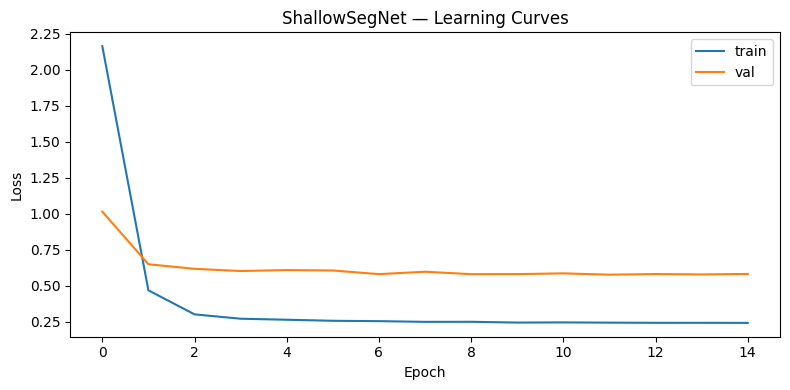

In [13]:
print("=" * 60)
print("Training Model 1: ShallowSegNet")
print("=" * 60)
model_shallow = ShallowSegNet().to(DEVICE)
hist_shallow  = train_model(model_shallow, loss_shallow,
                            EPOCHS_SHALLOW, "ckpt_shallow.pt")
plot_history(hist_shallow, "ShallowSegNet — Learning Curves")


### Model 2 — U-Net (small)

Training Model 2: U-Net (small, base=32)


  Epoch   1/30  train=1.8653  val=1.6772  ✓


  Epoch   2/30  train=1.0833  val=0.9602  ✓


  Epoch   3/30  train=0.7365  val=0.8430  ✓


  Epoch   4/30  train=0.6641  val=0.8215  ✓


...

  Epoch  26/30  train=0.5965  val=0.7369  ✓


  Epoch  27/30  train=0.5963  val=0.7339  ✓


  Epoch  28/30  train=0.5949  val=0.7278  ✓


  Epoch  29/30  train=0.5946  val=0.7314


  Epoch  30/30  train=0.5945  val=0.7313
  Best val loss: 0.7278  — checkpoint: /content/raidium/ckpt_unet.pt


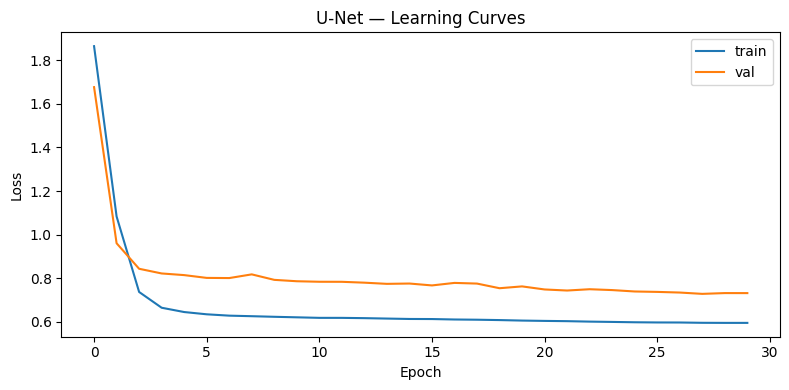

In [14]:
print("=" * 60)
print("Training Model 2: U-Net (small, base=32)")
print("=" * 60)
model_unet = UNet().to(DEVICE)
hist_unet  = train_model(model_unet, loss_unet,
                         EPOCHS_UNET, "ckpt_unet.pt")
plot_history(hist_unet, "U-Net — Learning Curves")


### Model 3 — U-Net+ (wider + class-weighted loss)

Training Model 3: U-Net+ (wide, base=48, class-weighted)


  Epoch   1/30  train=2.3796  val=2.3954  ✓


  Epoch   2/30  train=2.1537  val=2.3021  ✓


  Epoch   3/30  train=2.0065  val=2.2270  ✓


  Epoch   4/30  train=1.9555  val=2.2672


...

  Epoch  26/30  train=1.2690  val=1.4544  ✓


  Epoch  27/30  train=1.2550  val=1.4432  ✓


  Epoch  28/30  train=1.2615  val=1.4512


  Epoch  29/30  train=1.2491  val=1.4483


  Epoch  30/30  train=1.2502  val=1.4524
  Best val loss: 1.4432  — checkpoint: /content/raidium/ckpt_unetp.pt


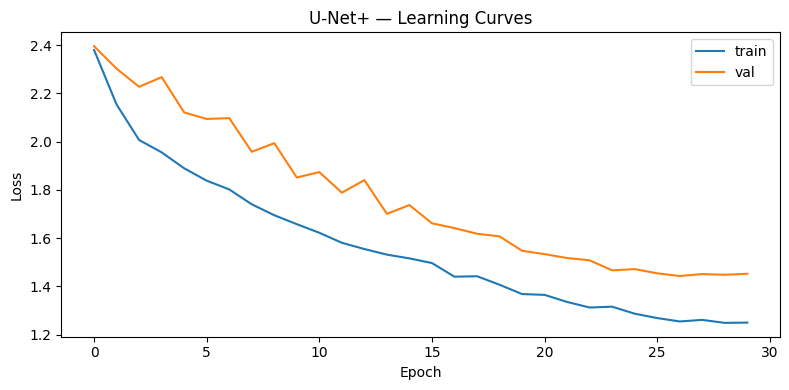

In [15]:
print("=" * 60)
print("Training Model 3: U-Net+ (wide, base=48, class-weighted)")
print("=" * 60)
model_unetp = UNetPlus().to(DEVICE)
hist_unetp  = train_model(model_unetp, loss_unetp,
                          EPOCHS_UNETP, "ckpt_unetp.pt")
plot_history(hist_unetp, "U-Net+ — Learning Curves")


## 8. Evaluation & Comparison <a id='evaluation'></a>

In [16]:
# ── Challenge Dice metric (verbatim from starter notebook) ───────────────────
def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))

def dice_multiclass(prediction, ground_truth):
    return np.array([
        dice_image(prediction == i, ground_truth == i)
        for i in range(1, NUM_CLASSES + 1)
    ])

def dice_pandas(y_true_df, y_pred_df):
    y_pred = y_pred_df.T
    y_true = y_true_df.T
    scores = [
        dice_multiclass(y_true.values[i].ravel(), y_pred.values[i].ravel())
        for i in range(y_true.values.shape[0])
    ]
    final = np.stack(scores)
    return float(np.nanmean(np.nanmean(final, axis=0))), np.nanmean(final, axis=0)


In [17]:
def predict_dataset(images, model, net_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """Run inference on a numpy image array → DataFrame (N, H*W)."""
    model.eval()
    all_preds = []
    for start in tqdm(range(0, len(images), batch_size), desc="Predicting"):
        batch = images[start : start + batch_size]
        t = torch.from_numpy(batch.astype(np.float32) / 255.0).unsqueeze(1)
        t = F.interpolate(t, size=net_size, mode="bilinear", align_corners=False).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            preds = model(t).argmax(dim=1, keepdim=True).float()
        preds = F.interpolate(preds, size=(IMG_H, IMG_W), mode="nearest")
        preds = preds.squeeze(1).cpu().numpy().astype(np.int32)
        all_preds.append(preds.reshape(len(batch), -1))
    return pd.DataFrame(np.concatenate(all_preds, axis=0))


labels_val_df = labels_train.iloc[:VAL_SPLIT]

print("Evaluating all models on validation set …")
results = {}
for name, mdl in [
    ("ShallowSegNet",   model_shallow),
    ("U-Net (small)",   model_unet),
    ("U-Net+ (wide)",   model_unetp),
]:
    preds_df = predict_dataset(val_imgs, mdl)
    overall, per_class = dice_pandas(labels_val_df, preds_df)
    results[name] = {"overall": overall, "per_class": per_class, "preds_df": preds_df}
    print(f"  {name:20s}  Dice = {overall:.6f}")

print("\nWatershed baseline Dice ≈ 0.0011")


Evaluating all models on validation set …


Predicting: 100%|██████████| 25/25 [00:00<00:00, 64.19it/s]


  ShallowSegNet         Dice = 0.000000


Predicting: 100%|██████████| 25/25 [00:01<00:00, 24.26it/s]


  U-Net (small)         Dice = 0.002378


Predicting: 100%|██████████| 25/25 [00:01<00:00, 13.73it/s]


  U-Net+ (wide)         Dice = 0.070492

Watershed baseline Dice ≈ 0.0011


In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = {"Watershed (baseline)": {"Overall Dice": 0.0011, "vs baseline": "1.0×"}}
for name, r in results.items():
    rows[name] = {
        "Overall Dice": r["overall"],
        "vs baseline": f"{r['overall'] / 0.0011:.1f}×",
    }
summary = pd.DataFrame(rows).T
print("\n=== Model comparison ===")
print(summary.to_string())



=== Model comparison ===
                     Overall Dice vs baseline
Watershed (baseline)       0.0011        1.0×
ShallowSegNet                 0.0        0.0×
U-Net (small)            0.002378        2.2×
U-Net+ (wide)            0.070492       64.1×


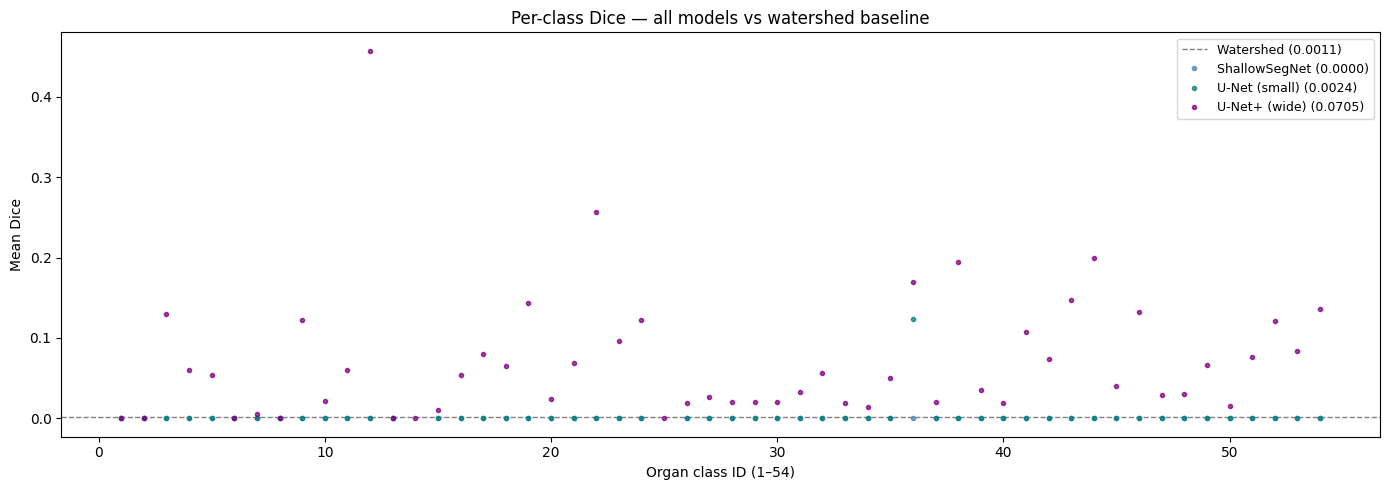

In [19]:
# ── Per-class Dice bar chart ──────────────────────────────────────────────────
classes = np.arange(1, NUM_CLASSES + 1)
colors  = {"ShallowSegNet": "steelblue", "U-Net (small)": "teal", "U-Net+ (wide)": "purple"}

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0.0011, color="gray", linestyle="--", linewidth=1, label="Watershed (0.0011)")

for name, color in colors.items():
    if name in results:
        ax.plot(classes, results[name]["per_class"], "o", markersize=3,
                color=color, alpha=0.75,
                label=f"{name} ({results[name]['overall']:.4f})")

ax.set_xlabel("Organ class ID (1–54)"); ax.set_ylabel("Mean Dice")
ax.set_title("Per-class Dice — all models vs watershed baseline")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


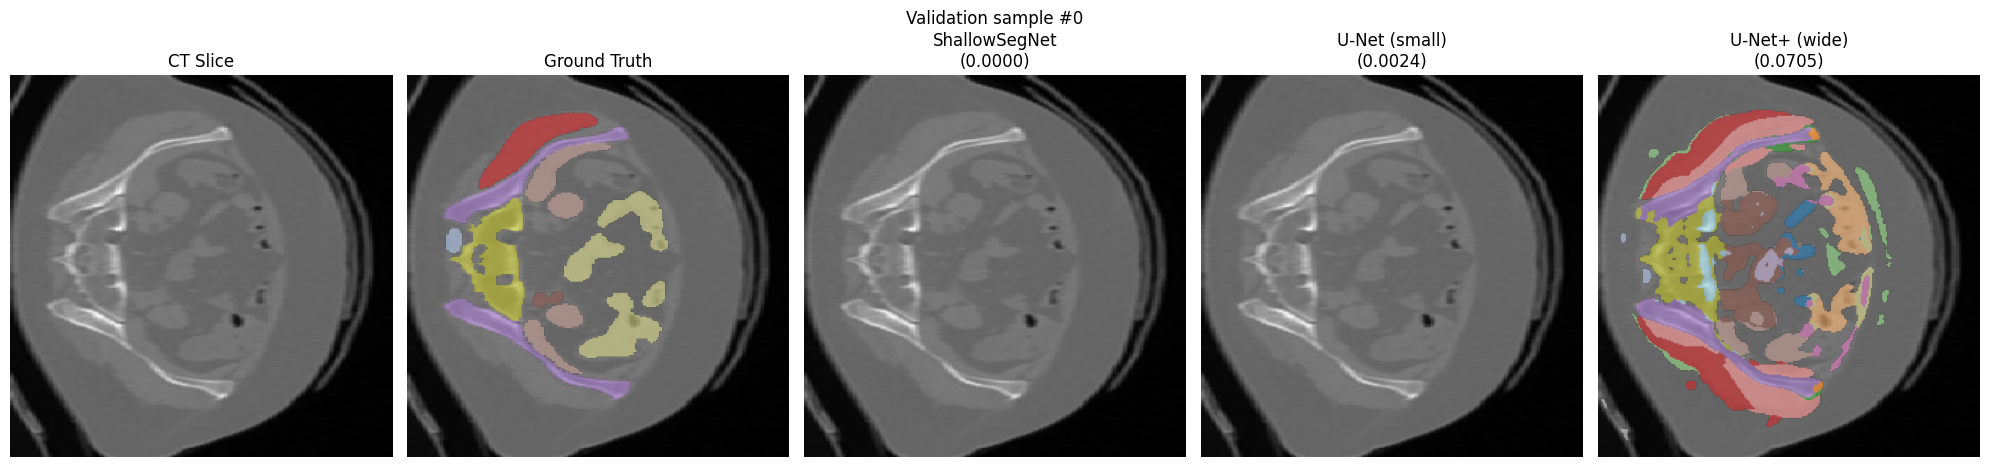

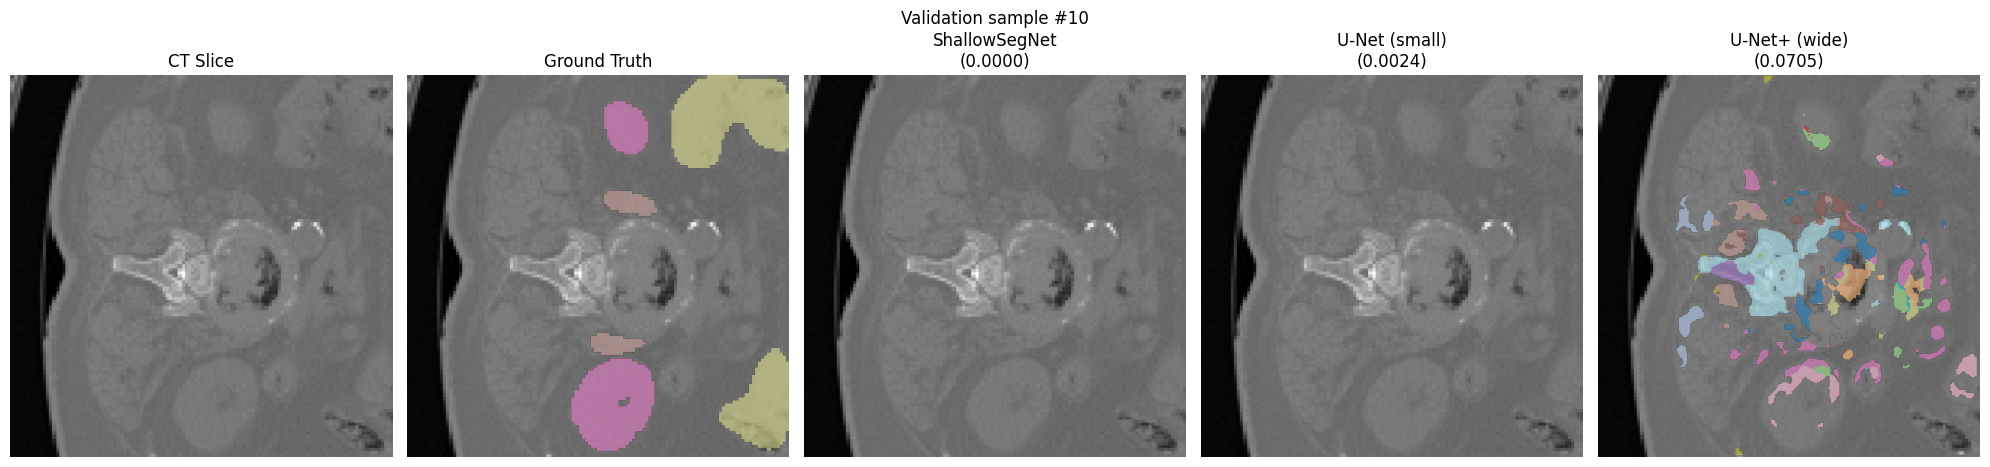

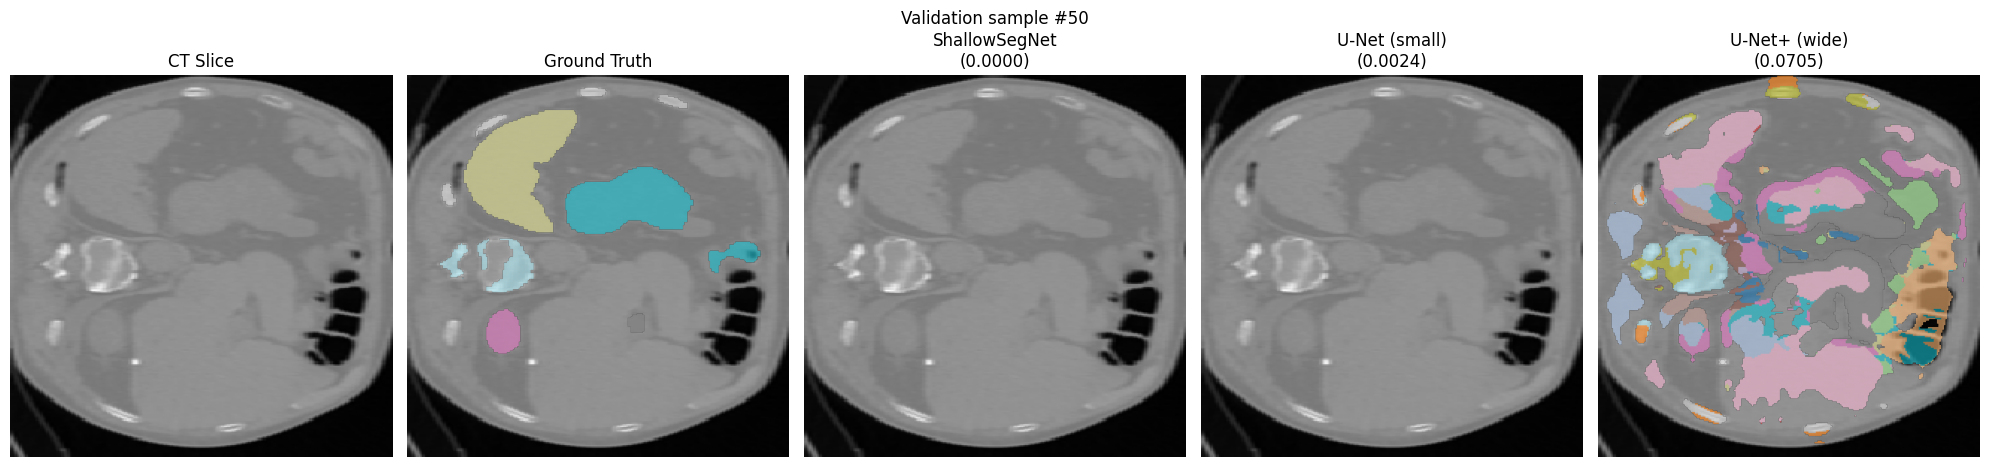

In [20]:
# ── Qualitative comparison (3 validation samples) ────────────────────────────
sample_ids = [0, 10, 50]

for idx in sample_ids:
    n_cols = 2 + len(results)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5))

    axes[0].imshow(val_imgs[idx], cmap="gray")
    axes[0].set_title("CT Slice"); axes[0].axis("off")

    gt = np.ma.masked_where(val_masks[idx] == 0, val_masks[idx])
    axes[1].imshow(val_imgs[idx], cmap="gray")
    axes[1].imshow(gt, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[1].set_title("Ground Truth"); axes[1].axis("off")

    for col, (name, r) in enumerate(results.items(), start=2):
        pr_arr = r["preds_df"].values.reshape(VAL_SPLIT, IMG_H, IMG_W)
        pr = np.ma.masked_where(pr_arr[idx] == 0, pr_arr[idx])
        axes[col].imshow(val_imgs[idx], cmap="gray")
        axes[col].imshow(pr, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
        axes[col].set_title(f"{name}\n({r['overall']:.4f})")
        axes[col].axis("off")

    fig.suptitle(f"Validation sample #{idx}"); plt.tight_layout(); plt.show()


## 9. Submission <a id='submission'></a>

In [21]:
# ── Pick the best model automatically ────────────────────────────────────────
best_name  = max(results, key=lambda k: results[k]["overall"])
best_model = {"ShallowSegNet": model_shallow,
              "U-Net (small)": model_unet,
              "U-Net+ (wide)": model_unetp}[best_name]

print(f"Best model : {best_name}  (Dice = {results[best_name]['overall']:.6f})")
print("Generating test predictions …")

test_preds_df = predict_dataset(data_test, best_model)
submission    = test_preds_df.T
submission.to_csv("/content/raidium/y_pred.csv")
print(f"Saved → /content/raidium/y_pred.csv  (shape: {submission.shape})")


Best model : U-Net+ (wide)  (Dice = 0.070492)
Generating test predictions …


Predicting: 100%|██████████| 63/63 [00:04<00:00, 13.89it/s]


Saved → /content/raidium/y_pred.csv  (shape: (65536, 500))


In [22]:
# ── Copy outputs back to Drive ────────────────────────────────────────────────
import shutil
shutil.copy("/content/raidium/y_pred.csv", str(DRIVE_DIR / "y_pred.csv"))
for ckpt in ["ckpt_shallow.pt", "ckpt_unet.pt", "ckpt_unetp.pt"]:
    src = LOCAL_DIR / ckpt
    if src.exists():
        shutil.copy(str(src), str(DRIVE_DIR / ckpt))
print("All outputs saved to Google Drive.")


All outputs saved to Google Drive.


---
## Possible Next Steps

1. **Increase resolution** — train at 512×512; T4 handles it at batch size 4
2. **Pre-trained encoder** — swap in a ResNet-50 or EfficientNet-B4 backbone via `segmentation_models_pytorch`
3. **Test-Time Augmentation (TTA)** — average predictions over flipped/rotated copies
4. **nnU-Net** — `pip install nnunetv2`; auto-configures everything for medical segmentation
5. **Ensemble** — average probability maps from all three models before argmax
